# TP 2 — NumPy : solution commentée

Solution complète du [TP 2](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import data

img = Image.fromarray(data.astronaut())
arr = np.array(img)
print(arr.shape, arr.dtype, arr.min(), arr.max())

(512, 512, 3) uint8 0 255


## Exercice 1 — Inspection et canaux

shape = (512, 512, 3)
dtype = uint8
min/mean/max = 0/114.6/255


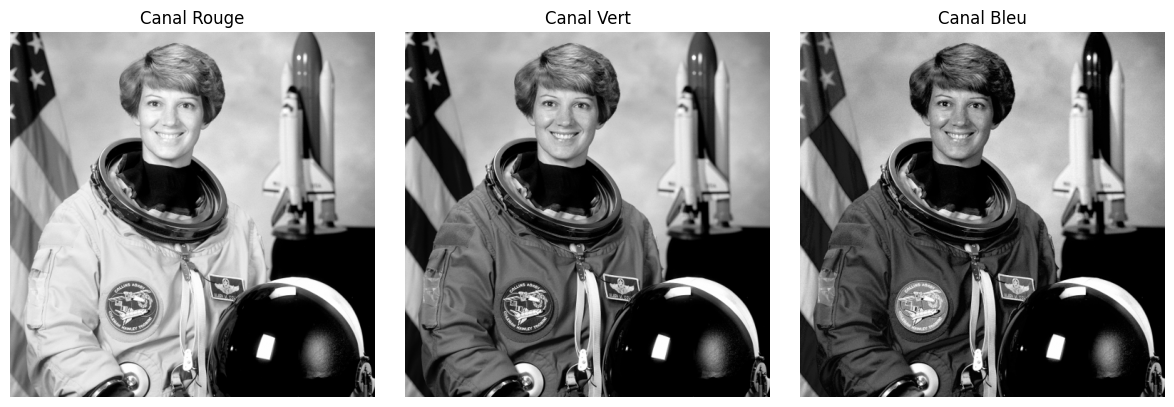

In [2]:
print(f"shape = {arr.shape}")
print(f"dtype = {arr.dtype}")
print(f"min/mean/max = {arr.min()}/{arr.mean():.1f}/{arr.max()}")

R = arr[..., 0]
G = arr[..., 1]
B = arr[..., 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ch, name in zip(axes, [R, G, B], ["Rouge", "Vert", "Bleu"]):
    ax.imshow(ch, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Canal {name}")
    ax.axis("off")
plt.tight_layout()

## Exercice 2 — Région d'intérêt et écriture

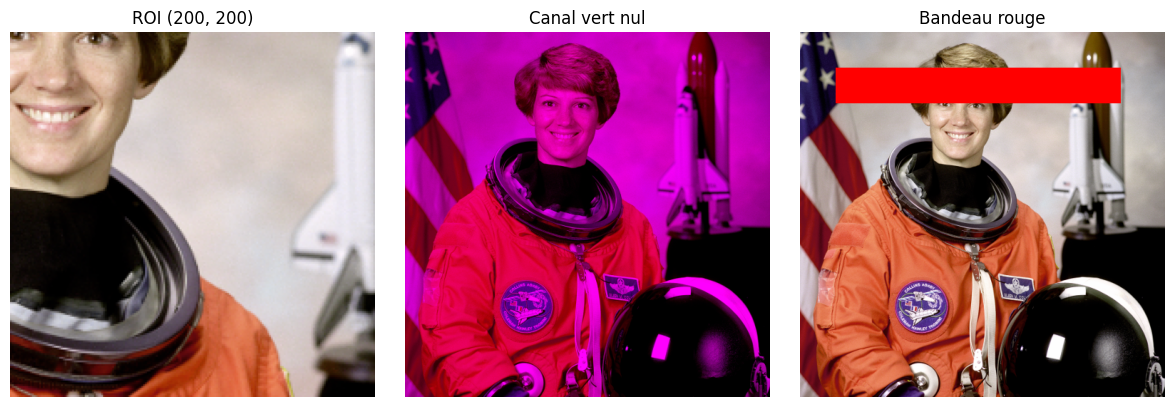

In [3]:
roi = arr[100:300, 200:400]

arr_no_green = arr.copy()
arr_no_green[..., 1] = 0

arr_red_band = arr.copy()
arr_red_band[50:100, 50:450] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(
    axes,
    [roi, arr_no_green, arr_red_band],
    [f"ROI {roi.shape[:2]}", "Canal vert nul", "Bandeau rouge"],
):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

## Exercice 3 — Opérations ponctuelles

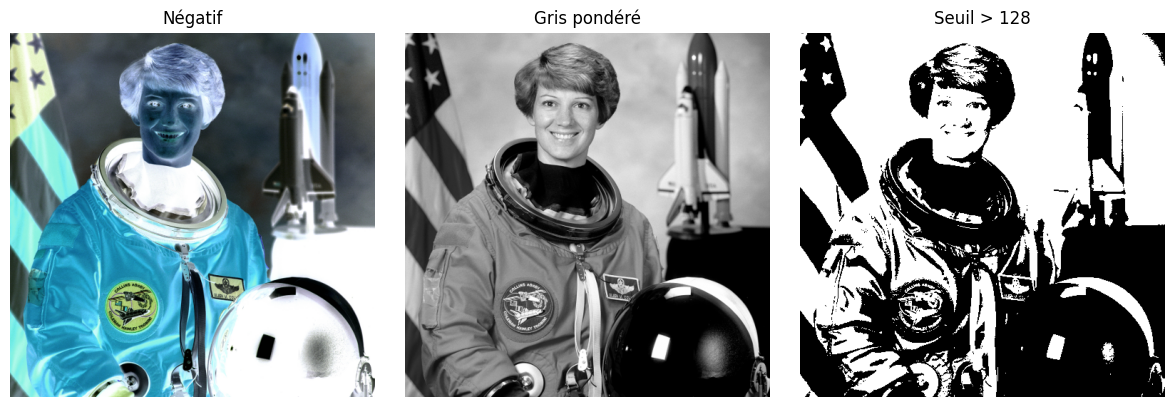

In [4]:
# 1. Négatif — attention au dtype : 255 - arr reste dans uint8 sans débordement.
neg = 255 - arr

# 2. Gris pondéré. On passe en float pour la multiplication, puis on repasse en uint8.
weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
gray = arr.astype(np.float32) @ weights  # shape (H, W), float32
gray = np.clip(gray, 0, 255).astype(np.uint8)

# 3. Seuillage à 128.
binar = (gray > 128).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(neg)
axes[0].set_title("Négatif")
axes[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Gris pondéré")
axes[2].imshow(binar, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Seuil > 128")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Exercice 4 — Image synthétique

In [7]:
rr, cc = np.indices((256, 256))

In [10]:
rr

array([[  0,   0,   0, ...,   0,   0,   0],
       [  1,   1,   1, ...,   1,   1,   1],
       [  2,   2,   2, ...,   2,   2,   2],
       ...,
       [253, 253, 253, ..., 253, 253, 253],
       [254, 254, 254, ..., 254, 254, 254],
       [255, 255, 255, ..., 255, 255, 255]], shape=(256, 256))

In [11]:
checker = (((rr // 32) + (cc // 32)) % 2).astype(np.uint8) * 255

In [14]:
rr // 32

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [7, 7, 7, ..., 7, 7, 7],
       [7, 7, 7, ..., 7, 7, 7],
       [7, 7, 7, ..., 7, 7, 7]], shape=(256, 256))

In [16]:
(((rr // 32) + (cc // 32)) % 2).astype(np.uint8)* 255

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0]], shape=(256, 256), dtype=uint8)

In [12]:
checker

array([[  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0],
       [255, 255, 255, ...,   0,   0,   0]], shape=(256, 256), dtype=uint8)

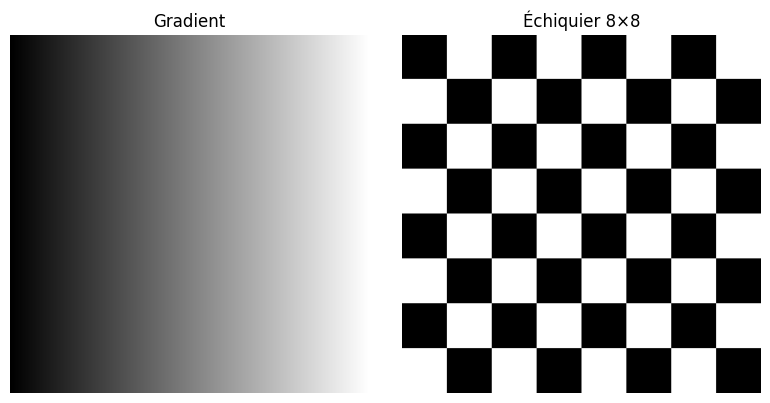

In [5]:
# 1. Gradient horizontal
row = np.linspace(0, 255, 256, dtype=np.uint8)  # (256,)
gradient = np.tile(row, (256, 1))  # (256, 256)

# 2. Échiquier 8x8 cases de 32x32 pixels — astuce : trier les cases avec une expression bool.
rr, cc = np.indices((256, 256))
checker = (((rr // 32) + (cc // 32)) % 2).astype(np.uint8) * 255

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gradient, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Gradient")
axes[1].imshow(checker, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Échiquier 8×8")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

## Exercice 5 — Mosaïque 2×2

Text(0.5, 1.0, 'Mosaïque 2×2')

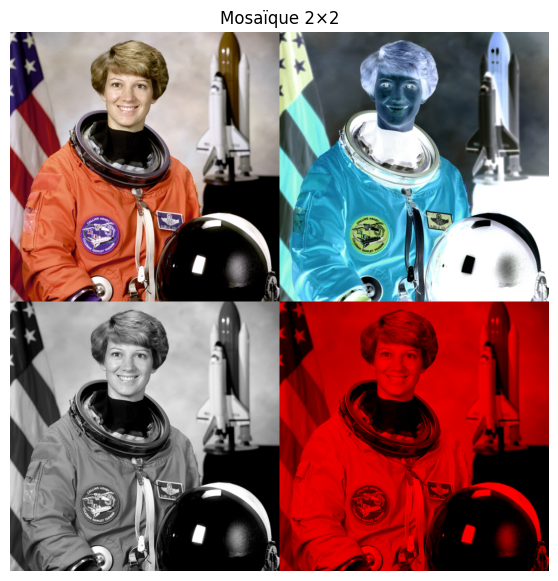

In [17]:
H, W = arr.shape[:2]

# 4 vignettes RGB de même taille.
v1 = arr
v2 = 255 - arr
v3 = np.stack([gray] * 3, axis=-1)  # gris répété sur 3 canaux
v4 = arr.copy()
v4[..., 1] = 0
v4[..., 2] = 0  # rouge uniquement

# Assemblage par np.vstack / np.hstack.
# Attention : np.block concatène sur les DERNIERS axes pour des tableaux 3D,
# ce qui ne donne pas une mosaïque 2×2 spatiale. On préfère vstack/hstack qui
# travaillent explicitement sur l'axe 0 (lignes) et 1 (colonnes).
top = np.hstack([v1, v2])
bot = np.hstack([v3, v4])
mosaic = np.vstack([top, bot])
assert mosaic.shape == (2 * H, 2 * W, 3)

Image.fromarray(mosaic).save("mosaique.png")
plt.figure(figsize=(7, 7))
plt.imshow(mosaic)
plt.axis("off")
plt.title("Mosaïque 2×2")